## Exploring Cross Infection between two variants
**Author:** Karen Guzman

**Description:** Exploring a two-variant SIR model with cross-infection. This is a cycle that allows individuals to become with variants multiple times. R1 contains individuals that have recovered from variant 1 and are temporarily cross-protected against variant 2 as well. A new parameter, omega, is introduced and represents the decay of cross-immunity from R1 -> S1 . This is a 7-compartment model containing groups S, I1, I2, R1, R2, S1, S2


**Date:** 7/3/2026

In [12]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../models')
#imports
import numpy as np
import matplotlib.pyplot as plt
import cross_infection_3 as ci

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Scenarios

**Scenario 1:** Waning immunity (omega) set to 0.0

[None]
  Variant 1 peak:   300.8 at t=38.3
  Variant 2 peak:     1.0 at t=60.0
  Never infected at end (S): 58.7


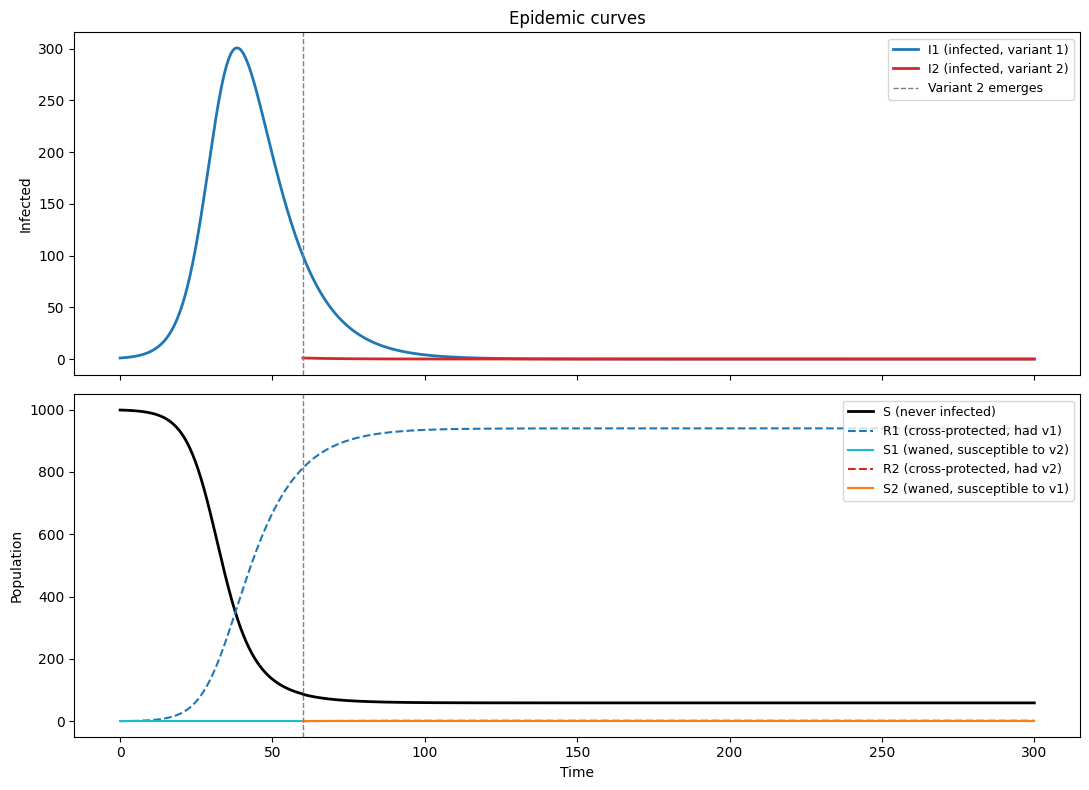

In [13]:
# omega = 0.0

params=[0.30, 0.25, 0.10, 0.10, 0.00] #beta1, beta2, gamma1, gamma2, omega
y0 = [999, 1, 0, 0, 0, 0, 0] 
t, y = ci.simulate_cross_infection(params, y0, t_emerge=60)

ci.plot_cross_infection(t, y)

When waning immunity is 0.0, cross-protection doesn't wane. People sit in R1 and R2 permanently and no one moves to S1 or S2. 

**Scenario 2:** Varying omega only

[None]
  Variant 1 peak:   300.8 at t=38.3
  Variant 2 peak:   182.0 at t=140.5
  Never infected at end (S): 0.9


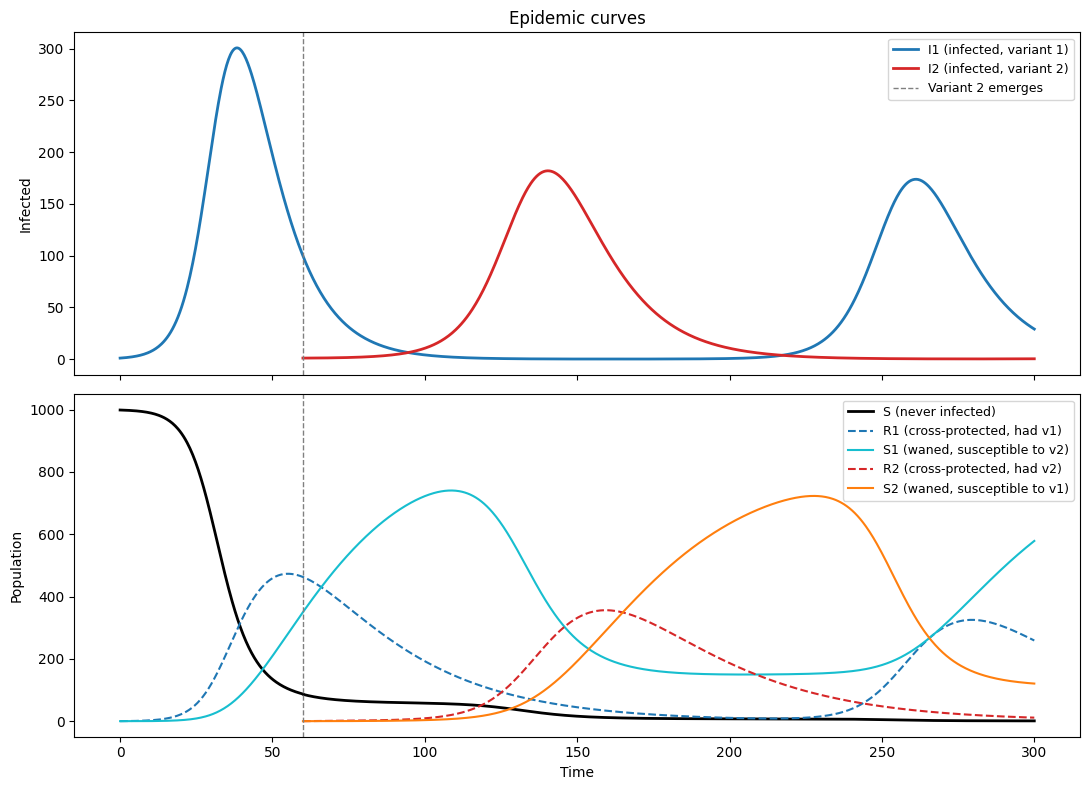

In [14]:
#omega = 0.03

params=[0.30, 0.25, 0.10, 0.10, 0.03] #beta1, beta2, gamma1, gamma2, omega
y0 = [999, 1, 0, 0, 0, 0, 0] 
t, y = ci.simulate_cross_infection(params, y0, t_emerge=60)

ci.plot_cross_infection(t, y)

[None]
  Variant 1 peak:   300.8 at t=38.3
  Variant 2 peak:   230.2 at t=112.6
  Never infected at end (S): 0.0


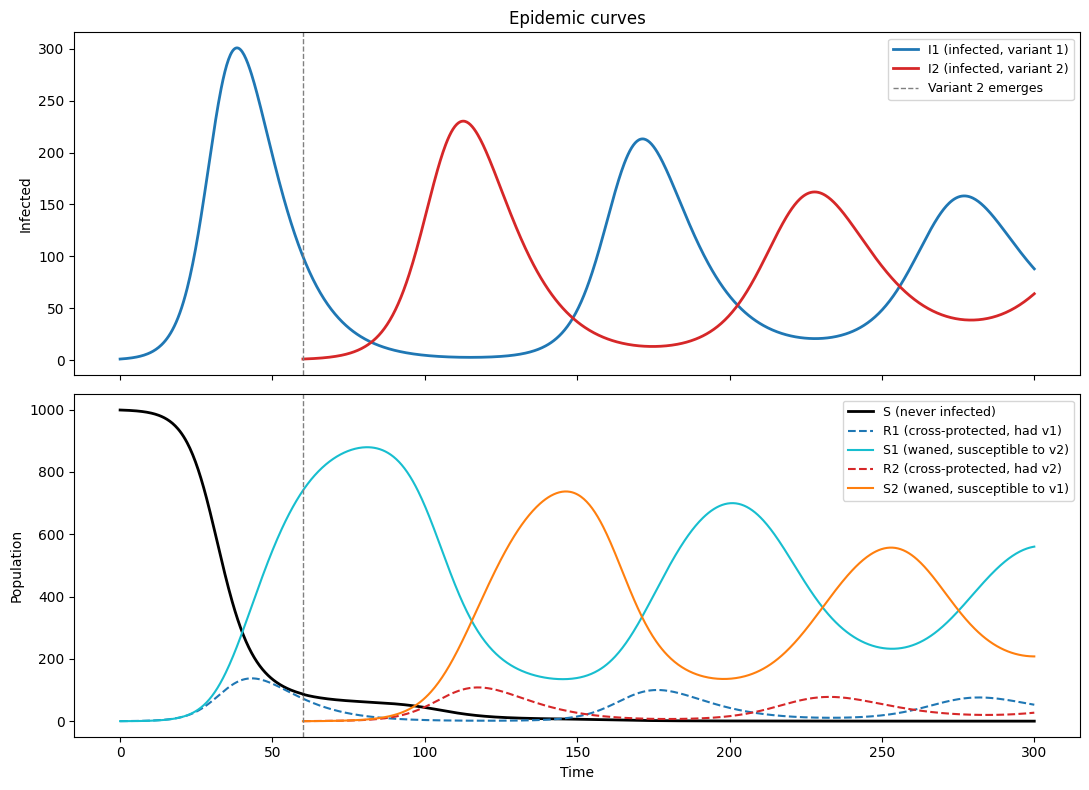

In [15]:
#raising omega to 0.2

params=[0.30, 0.25, 0.10, 0.10, 0.20] #beta1, beta2, gamma1, gamma2, omega
y0 = [999, 1, 0, 0, 0, 0, 0] 
t, y = ci.simulate_cross_infection(params, y0, t_emerge=60)

ci.plot_cross_infection(t, y)

A small value of omega = 0.03 gives slow waves in the infections of both variants. Raising omega to 0.2 means that individuals are moving quicker to susceptible population of the other variant once they recover from the first. This shortening of the cross-immunity period means there more frequent waves in the same time period.

**Scenario 3:** Omega fixed at 0.03 and varying beta2 only

[None]
  Variant 1 peak:   300.8 at t=38.3
  Variant 2 peak:     1.0 at t=60.0
  Never infected at end (S): 58.7


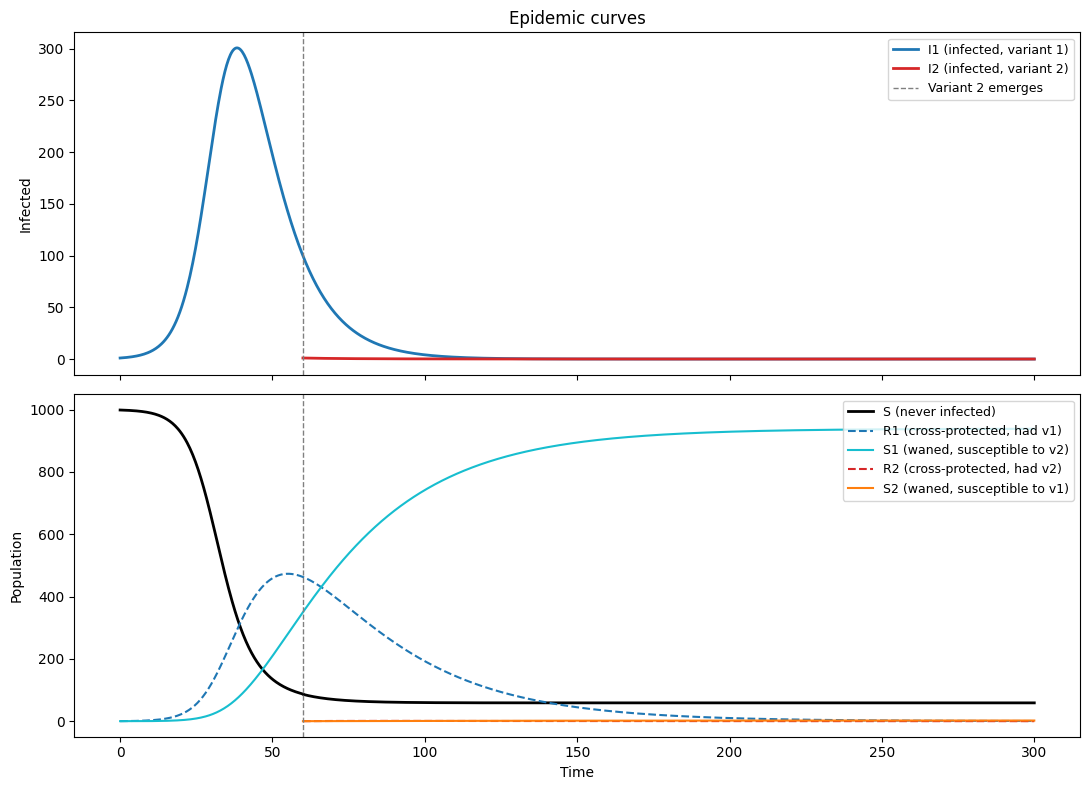

In [16]:
params=[0.30, 0.08, 0.10, 0.10, 0.03] #beta1, beta2, gamma1, gamma2, omega
y0 = [999, 1, 0, 0, 0, 0, 0] 
t, y = ci.simulate_cross_infection(params, y0, t_emerge=60)

ci.plot_cross_infection(t, y)

[None]
  Variant 1 peak:   300.8 at t=38.3
  Variant 2 peak:   277.6 at t=102.1
  Never infected at end (S): 0.0


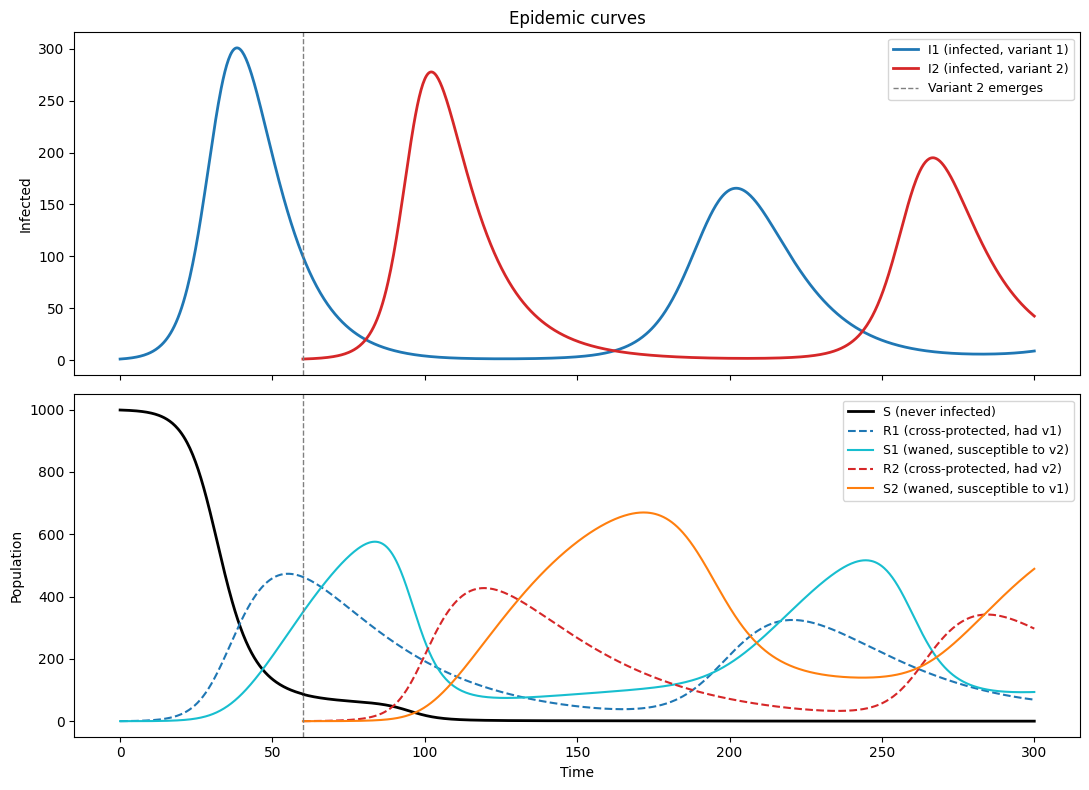

In [17]:
params=[0.30, 0.45, 0.10, 0.10, 0.03] #beta1, beta2, gamma1, gamma2, omega
y0 = [999, 1, 0, 0, 0, 0, 0] 
t, y = ci.simulate_cross_infection(params, y0, t_emerge=60)

ci.plot_cross_infection(t, y)

In the first graph with a beta2 of 0.08, no new individuals are infected with variant two because of how small the transmission rate is. In the second graph once beta2 is raised to 0.45, the first peak of the second variant is smaller than the first peak of the first variant. However, when second oscillation comes around, the second variant's peak is higher than the first variant's.

**Scenario 4:**  Beta2 back to 0.25, vary gamma2 only

[None]
  Variant 1 peak:   300.8 at t=38.3
  Variant 2 peak:   379.8 at t=124.6
  Never infected at end (S): 0.0


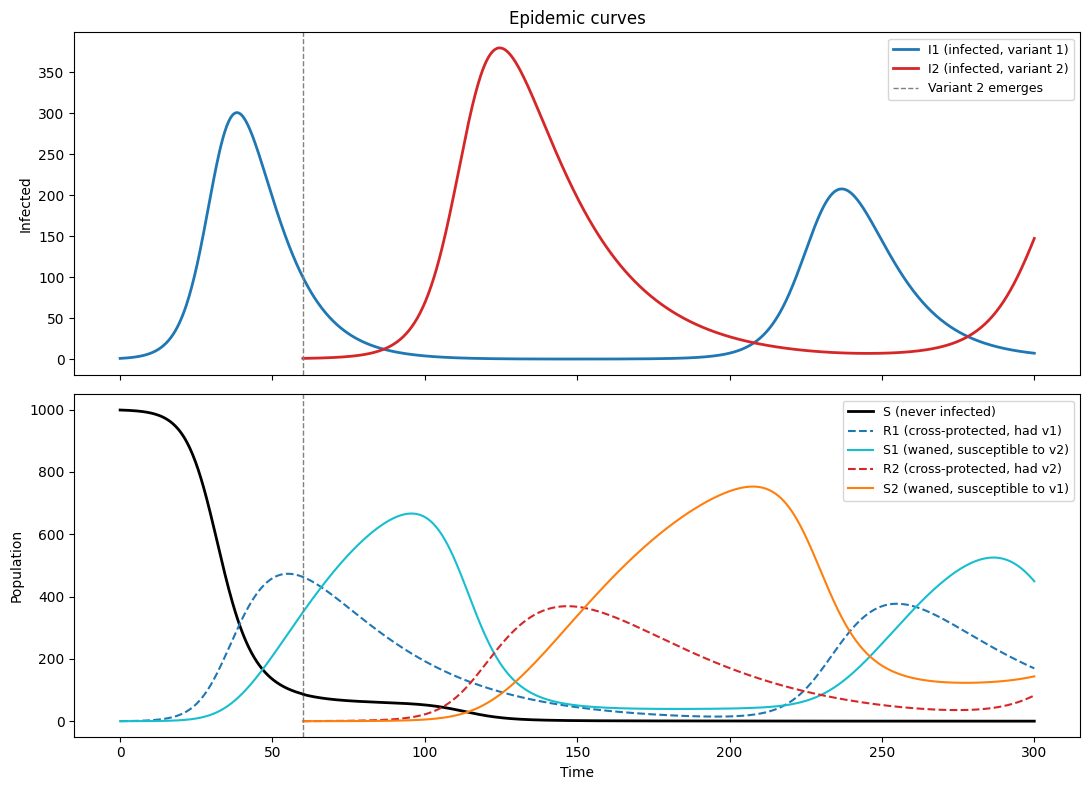

In [18]:
params=[0.30, 0.25, 0.10, 0.05, 0.03] #beta1, beta2, gamma1, gamma2, omega
y0 = [999, 1, 0, 0, 0, 0, 0] 
t, y = ci.simulate_cross_infection(params, y0, t_emerge=60)

ci.plot_cross_infection(t, y)

[None]
  Variant 1 peak:   300.8 at t=38.3
  Variant 2 peak:    76.9 at t=172.9
  Never infected at end (S): 19.9


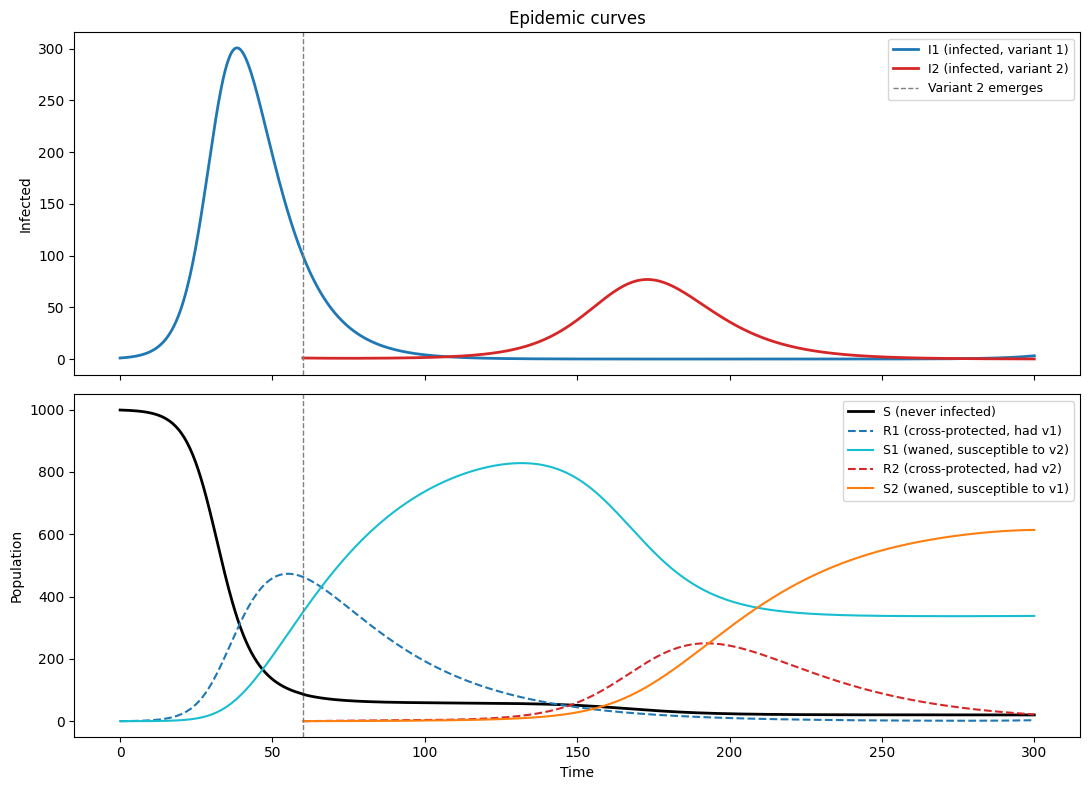

In [19]:
params=[0.30, 0.25, 0.10, 0.15, 0.03] #beta1, beta2, gamma1, gamma2, omega
y0 = [999, 1, 0, 0, 0, 0, 0] 
t, y = ci.simulate_cross_infection(params, y0, t_emerge=60)

ci.plot_cross_infection(t, y)

Raising gamma2 means that variant 2 people recover faster, which lowers the reproduction number to $R_02 = 0.25/0.15 = 1.67$ This means it's a weaker variant and it spreads slowly. The long wave has a peak at 76.9 and can't spread quickly over the entire population. 